# Text-Embeddings mit einem lokalen Ollama-Server

Begleit-Notebook zum Vortrag `90_Ollama`. Wir beantworten experimentell drei Fragen:

1. Wie sehen Embedding-Vektoren konkret aus?
2. Wie messen wir, ob sich zwei Texte semantisch ähneln?
3. Lässt sich damit eine kleine semantische Suche bauen?

Voraussetzung: Ein laufender Ollama-Server unter `http://localhost:11434` mit geladenem Modell `bge-m3`. Siehe `README.md`.

## 1. Verbindung zum Ollama-Server

Wir sprechen Ollama über das `openai`-SDK an – identisch zum Cloud-Code, nur mit anderer `base_url` und einem Dummy-`api_key` (Ollama prüft das Feld nicht, verlangt es aber als Wert).

Als Embedding-Modell nutzen wir `bge-m3` – ein multilinguales Modell, das auch auf deutschen Texten stabile, bedeutungsbasierte Vektoren liefert. Ein englisch-zentriertes Modell (z. B. `nomic-embed-text`) würde bei unserem deutschen Korpus stark auf Oberflächenmerkmale (Satzbau, Eigennamen) achten und die Cluster verwässern.

In [57]:
from openai import OpenAI
import numpy as np
import pandas as pd

EMBED_MODEL = "mxbai-embed-large"

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)

ping = client.embeddings.create(model=EMBED_MODEL, input="Hallo")
print(f"Modell erreichbar. Vektor-Dimension: {len(ping.data[0].embedding)}")

Modell erreichbar. Vektor-Dimension: 1024


## 2. Ein thematisch gemischtes Korpus

Wir stellen Sätze aus vier Themenbereichen zusammen:

+ **Universitäten in Sachsen** – semantisch eng beieinander.
+ **Bergbau/Geowissenschaft** – hat fachliche Nähe zur TUBAF, aber nicht zum Hochschulbetrieb.
+ **Fußball** – völlig anderer Themenkreis, sollte klar separieren.
+ **Kulinarik (sächsisch)** – teilt lexikalisch das Wort „sächsisch“ mit den Uni-Sätzen, ist aber inhaltlich fern.

Ein gutes Embedding sollte das Wortoberflächen-Argument gegen das Bedeutungs-Argument eintauschen.

In [58]:
korpus = [
    # Universitäten in Sachsen
    ("uni_freiberg", "Die TU Bergakademie Freiberg ist eine Universität mit Schwerpunkt auf Ressourcen, Geowissenschaften und Materialforschung."),
    ("uni_leipzig",  "Die Universität Leipzig ist mit über 30 000 Studierenden eine der größten Universitäten in Sachsen."),
    ("uni_dresden",  "Die TU Dresden ist eine Exzellenzuniversität mit starkem Ingenieur- und Naturwissenschaftsprofil."),

    # Bergbau und Geowissenschaft
    ("bergbau",      "Der Erzbergbau im Erzgebirge prägt die Region seit dem zwölften Jahrhundert."),
    ("geologie",     "Geologie umfasst den Aufbau, Zusammensetzung und Struktur der Erdkruste und die Eigenschaften ihrer Gesteine."),

    # Fußball
    ("fussball_1",   "Der Fußballverein Dynamo Dresden spielt derzeit in der Zweiten Bundesliga."),
    ("fussball_2",   "RB Leipzig hat das Halbfinale der Champions League erreicht."),

    # Sächsische Kulinarik
    ("kuchen",       "Ein Rezept für klassischen sächsischen Apfelkuchen mit Streuseln und Zimt."),
    ("quarkkeulchen","Quarkkeulchen sind eine sächsische Süßspeise aus Quark, gekochten Kartoffeln und Zucker."),
]

labels = [k for k, _ in korpus]
texte  = [t for _, t in korpus]

pd.DataFrame(korpus, columns=["Label", "Text"])

,Label,Text
0,uni_freiberg,Die TU Bergakademie Freiberg ist eine Universi...
1,uni_leipzig,Die Universität Leipzig ist mit über 30 000 St...
2,uni_dresden,Die TU Dresden ist eine Exzellenzuniversität m...
3,bergbau,Der Erzbergbau im Erzgebirge prägt die Region ...
4,geologie,"Geologie umfasst den Aufbau, Zusammensetzung u..."
5,fussball_1,Der Fußballverein Dynamo Dresden spielt derzei...
6,fussball_2,RB Leipzig hat das Halbfinale der Champions Le...
7,kuchen,Ein Rezept für klassischen sächsischen Apfelku...
8,quarkkeulchen,Quarkkeulchen sind eine sächsische Süßspeise a...


## 3. Embeddings anfordern

Ein einziger API-Aufruf mit der Text-Liste – Ollama liefert pro Text einen Vektor.

In [59]:
resp = client.embeddings.create(model=EMBED_MODEL, input=texte)
vektoren = np.array([e.embedding for e in resp.data])

print(f"Matrix-Form: {vektoren.shape}  (Zeilen = Texte, Spalten = Vektor-Dimensionen)")
print(f"\nErste 8 Werte des TUBAF-Vektors:\n{vektoren[0, :8]}")
print(f"\nNorm des TUBAF-Vektors: {np.linalg.norm(vektoren[0]):.4f}")

Matrix-Form: (9, 1024)  (Zeilen = Texte, Spalten = Vektor-Dimensionen)

Erste 8 Werte des TUBAF-Vektors:
[-0.00780597  0.00360987  0.02146103  0.0011989   0.01744471  0.09564853
  0.01935548 -0.0144556 ]

Norm des TUBAF-Vektors: 1.0000


## 4. Paarweise Kosinus-Ähnlichkeit

Für zwei Vektoren $\vec a$ und $\vec b$:

$$
\text{cos\_sim}(\vec a, \vec b) = \frac{\vec a \cdot \vec b}{\|\vec a\| \; \|\vec b\|}
$$

Wir berechnen die komplette Matrix auf einmal: L2-normalisieren, dann Skalarprodukt – so werden Norm-Divisionen zu einer Matrix-Multiplikation.

In [60]:
normen = np.linalg.norm(vektoren, axis=1, keepdims=True)
v_norm = vektoren / normen
sim = v_norm @ v_norm.T

sim_df = pd.DataFrame(sim, index=labels, columns=labels).round(3)
sim_df

,uni_freiberg,uni_leipzig,uni_dresden,bergbau,geologie,fussball_1,fussball_2,kuchen,quarkkeulchen
uni_freiberg,1.000,0.580,0.717,0.649,0.756,0.426,0.408,0.572,0.550
uni_leipzig,0.580,1.000,0.651,0.572,0.499,0.501,0.581,0.584,0.501
uni_dresden,0.717,0.651,1.000,0.558,0.618,0.577,0.474,0.589,0.576
bergbau,0.649,0.572,0.558,1.000,0.688,0.500,0.506,0.645,0.595
geologie,0.756,0.499,0.618,0.688,1.000,0.445,0.431,0.606,0.572
fussball_1,0.426,0.501,0.577,0.500,0.445,1.000,0.674,0.519,0.535
fussball_2,0.408,0.581,0.474,0.506,0.431,0.674,1.000,0.548,0.498
kuchen,0.572,0.584,0.589,0.645,0.606,0.519,0.548,1.000,0.747
quarkkeulchen,0.550,0.501,0.576,0.595,0.572,0.535,0.498,0.747,1.000


### Die interessantesten Paare

Wir ziehen das obere Dreieck aus der Matrix, sortieren absteigend nach Ähnlichkeit und schauen uns die Extreme an.

In [61]:
paare = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        paare.append((labels[i], labels[j], sim[i, j]))

paare_df = (pd.DataFrame(paare, columns=["A", "B", "cos_sim"])
              .sort_values("cos_sim", ascending=False)
              .reset_index(drop=True))

print("Top 5 – semantisch nächste Paare:")
print(paare_df.head(5).to_string(index=False))
print("\nBottom 5 – semantisch entfernteste Paare:")
print(paare_df.tail(5).to_string(index=False))

Top 5 – semantisch nächste Paare:
           A             B  cos_sim
uni_freiberg      geologie 0.755743
      kuchen quarkkeulchen 0.747441
uni_freiberg   uni_dresden 0.716830
     bergbau      geologie 0.687568
  fussball_1    fussball_2 0.673906

Bottom 5 – semantisch entfernteste Paare:
           A          B  cos_sim
 uni_dresden fussball_2 0.473946
    geologie fussball_1 0.445117
    geologie fussball_2 0.430894
uni_freiberg fussball_1 0.425521
uni_freiberg fussball_2 0.408185


**Worauf wir achten:**

+ Die drei Universitäts-Sätze sollten untereinander die höchsten Werte haben.
+ `kuchen` und `quarkkeulchen` sollten ein gemeinsames Cluster bilden – beide „sächsische Kulinarik“.
+ `fussball_2` (_RB Leipzig_) und `uni_leipzig` teilen das Wort „Leipzig“ – das Embedding sollte sich aber nicht allein davon leiten lassen.
+ `bergbau` hat thematisch Nähe zur TUBAF (Ressourcen, Geo) – interessante Zwischenposition.

## 5. Heatmap der Ähnlichkeitsmatrix

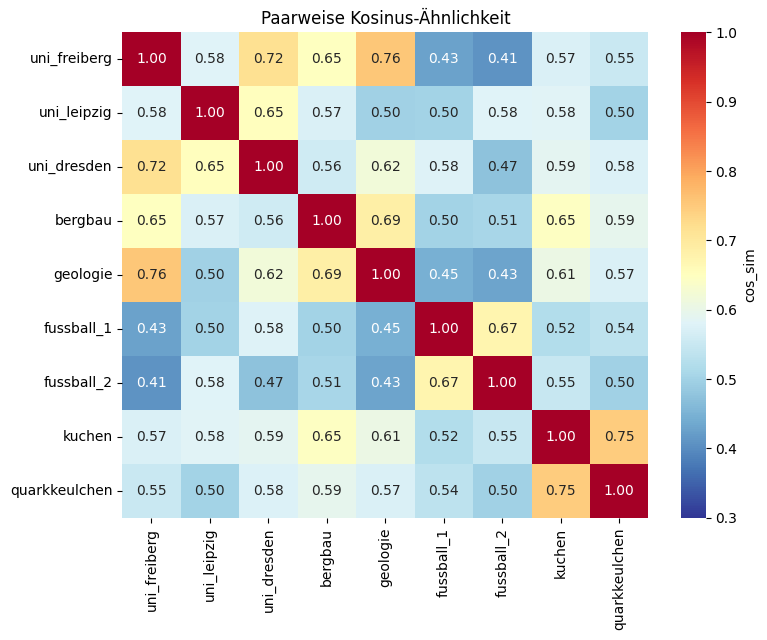

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="RdYlBu_r",
            vmin=0.3, vmax=1.0, cbar_kws={"label": "cos_sim"}, ax=ax)
ax.set_title("Paarweise Kosinus-Ähnlichkeit")
plt.tight_layout()
plt.show()

## 6. PCA-Projektion: 1024 Dimensionen auf eine Ebene

Eine Heatmap ist präzise, aber wenig anschaulich. Eine **Hauptkomponenten-Analyse** projiziert die 1024-dimensionalen Vektoren auf zwei Achsen, die möglichst viel der ursprünglichen Varianz bewahren.

Wichtig: Die Abstände in der PCA-Ebene sind **nur eine Näherung** an die echte Metrik. Aber für ein Gefühl, welche Sätze sich im Raum gruppieren, genügt es.

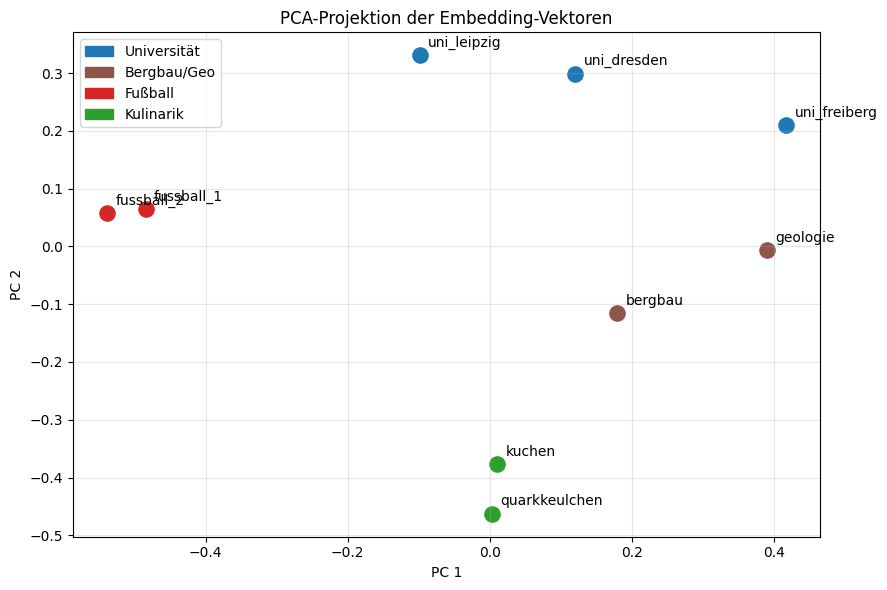

In [63]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=0).fit_transform(vektoren)

gruppen = {
    "Universität":  ["uni_freiberg", "uni_leipzig", "uni_dresden"],
    "Bergbau/Geo":  ["bergbau", "geologie"],
    "Fußball":      ["fussball_1", "fussball_2"],
    "Kulinarik":    ["kuchen", "quarkkeulchen"],
}
farbe_je_label = {lbl: farbe
                  for gruppe, farbe in zip(gruppen, ["#1f77b4", "#8c564b", "#d62728", "#2ca02c"])
                  for lbl in gruppen[gruppe]}

fig, ax = plt.subplots(figsize=(9, 6))
for i, lbl in enumerate(labels):
    ax.scatter(coords[i, 0], coords[i, 1], s=120, color=farbe_je_label[lbl])
    ax.annotate(lbl, (coords[i, 0], coords[i, 1]),
                xytext=(6, 6), textcoords="offset points", fontsize=10)

from matplotlib.patches import Patch
legende = [Patch(color=f, label=g)
           for g, f in zip(gruppen, ["#1f77b4", "#8c564b", "#d62728", "#2ca02c"])]
ax.legend(handles=legende, loc="best")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA-Projektion der Embedding-Vektoren")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Semantische Suche – das einfachste RAG

Jetzt die eigentliche Anwendung: zu einer Freitext-Frage den **inhaltlich passendsten** Satz aus dem Korpus finden. Das ist die Bausteine, aus denen eine Vektor-Datenbank ihre Treffer liefert.

Kein Keyword-Matching, keine Regex – wir rechnen einfach einen neuen Vektor und nehmen den nächsten Nachbarn.

In [64]:
def suche(query: str, top_k: int = 3) -> pd.DataFrame:
    """Nächste `top_k` Sätze aus dem Korpus zur Freitext-Anfrage."""
    q_vec = np.array(client.embeddings.create(model=EMBED_MODEL, input=query).data[0].embedding)
    q_vec /= np.linalg.norm(q_vec)

    scores = v_norm @ q_vec
    ordnung = np.argsort(-scores)[:top_k]

    return pd.DataFrame({
        "Rang":    range(1, top_k + 1),
        "Label":   [labels[i] for i in ordnung],
        "cos_sim": [round(float(scores[i]), 3) for i in ordnung],
        "Text":    [texte[i] for i in ordnung],
    })

suche("Welche Hochschulen gibt es in Sachsen?")

,Rang,Label,cos_sim,Text
0,1,uni_leipzig,0.754,Die Universität Leipzig ist mit über 30 000 St...
1,2,uni_dresden,0.637,Die TU Dresden ist eine Exzellenzuniversität m...
2,3,kuchen,0.569,Ein Rezept für klassischen sächsischen Apfelku...


In [65]:
suche("Wo werden Erze abgebaut?")

,Rang,Label,cos_sim,Text
0,1,bergbau,0.679,Der Erzbergbau im Erzgebirge prägt die Region ...
1,2,kuchen,0.646,Ein Rezept für klassischen sächsischen Apfelku...
2,3,geologie,0.630,"Geologie umfasst den Aufbau, Zusammensetzung u..."


In [66]:
suche("Was esse ich zum Kaffee?")

,Rang,Label,cos_sim,Text
0,1,kuchen,0.615,Ein Rezept für klassischen sächsischen Apfelku...
1,2,quarkkeulchen,0.571,Quarkkeulchen sind eine sächsische Süßspeise a...
2,3,bergbau,0.537,Der Erzbergbau im Erzgebirge prägt die Region ...


In [67]:
suche("Wer ist ins Halbfinale eingezogen?")

,Rang,Label,cos_sim,Text
0,1,kuchen,0.626,Ein Rezept für klassischen sächsischen Apfelku...
1,2,bergbau,0.593,Der Erzbergbau im Erzgebirge prägt die Region ...
2,3,geologie,0.581,"Geologie umfasst den Aufbau, Zusammensetzung u..."


## Fazit

+ Ein Embedding ist nichts Magisches – eine Liste von 1024 Fließkommazahlen pro Text.
+ Die Kosinus-Ähnlichkeit liefert ein robustes, längenunabhängiges Maß für Bedeutungsnähe.
+ PCA hilft beim **Gefühl** für die Struktur, ist aber keine Ersatz-Metrik.
+ Semantische Suche ist: Embedding der Frage, Skalarprodukt mit allen normalisierten Dokumentvektoren, Top-k. Alles weitere (Vektor-Datenbanken, Chunking, Re-Ranking) ist Skalierungs-Engineering.
+ Das komplette Experiment lief **ausschließlich auf dem eigenen Rechner** – kein Byte verlässt den Laptop.